## Neural Network Model #1: **Multi-Layer Perceptron**

First, we will import our pre-split and scaled training, validation, and test sets.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

# make sure torch is installed
import sys
!{sys.executable} -m pip install torch

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

In [2]:
from MCO_functions import trainNetwork, evaluateNetwork
from MCO_functions import DataLoader
from MCO_functions import NeuralNetwork
import torch.optim as optim
import torch.nn as nn
import numpy as np

# Ensure deterministic behavior for reproducibility
import torch, numpy as np, random, os

%load_ext autoreload
%autoreload 2

In [3]:
# load data into PyTorch tensors
nn_X_train = torch.from_numpy(X_train_scaled.to_numpy()).float()
nn_y_train = torch.from_numpy(y_train.to_numpy()).long()

nn_X_val = torch.from_numpy(X_val_scaled.to_numpy()).float()
nn_y_val = torch.from_numpy(y_val.to_numpy()).long()

nn_X_test = torch.from_numpy(X_test_scaled.to_numpy()).float()
nn_y_test = torch.from_numpy(y_test.to_numpy()).long()

# determine input size based on features in X train
input_size = nn_X_train.shape[1]
input_size

85

# **[4]** Model Selection Training


In predicting urban and rural households, we employ a multi-layer perceptron, as these are known to be effective at handling non-linear problems and large datasets.

https://www.datacamp.com/tutorial/multilayer-perceptrons-in-machine-learning  
https://h2o.ai/wiki/multilayer-perceptron/  

To get more effective final model, we accomplish the following:

1. Preliminary comparison of different neural network architectures
2. Comparison of hyperparameter configurations of the selected architecture(s)
3. Error analysis of the selected model and tuning

### Preliminary Comparison of different Neural Network Architectures

Rectified Linear Units (ReLu) is used as the activation function in training the neural networks for its less expensive computation compared to sigmoid.
$$
ReLU(x)=max(0,x)
$$

$$
f(x)=
\begin{cases}
0 & \text{if } x < 0 \\
1 & \text{if } x \geq 0 
\end{cases}
$$  

Adam is used as the optimizer as it is known for having faster convergance and an adaptive learning rate and reduced sensitivity to hyperparameters.

https://arxiv.org/abs/1412.6980  
https://arxiv.org/abs/1904.09237

We perform an initial grid search over different possible neural network architectures and compare their performance metrics in order to get a better configuration for the final model. These architectures follow the pyramid pattern, where after the first hidden layer, each layer has half the neurons of the previous. This approach is known to be more effective for tabular data.  

https://machinelearningtheory.org/docs/Deep-Learning/designing-the-architecture/  

An initial learning rate of 0.005 and a relatively smaller epoch limit of 15 is used to speed up the preliminary search. Each network architecture is trained and evaluated using multiple seeds, with each of their resulting metrics averaged across runs to provide more stable performance estimates.

In [4]:
learning_rate = 0.005
# a relatively small epoch limit to prevent long training times during preliminary search
epoch_limit = 15

seeds = [0, 42, 123, 456, 789]  # different for multiple runs

# Define different architectures to test (number of hidden layers and their sizes)
configs = [
    (64, 32),
    (128, 64),
    (256, 128),
    (128, 64, 32),
    (256, 128, 64)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train and evaluate the neural network for each architecture configuration
criterion = nn.CrossEntropyLoss()
data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=64)

for hidden_layers in configs:

    run_metrics = []  # to store metrics for this architecture

    for seed in seeds:
        # Set seeds for reproducibility
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

        network = NeuralNetwork(
            input_size=input_size,
            list_hidden=hidden_layers,
            activation='relu',
            num_classes=2
        )

        print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}")

        network.create_network()

        optimizer = optim.Adam(network.parameters(), lr=learning_rate)

        training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

        loss_history.append({
            "architecture": hidden_layers,
            "seed": seed,
            "losses": training_losses
        })

        # evaluate on both train and validation sets
        trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
        evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

        # store metrics of this run
        run_metrics.append({
            "train": trainMetrics,
            "val": evalMetrics
        })
    
    # Collect all training confusion matrices
    train_cms = [r['train']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['train']]
    avg_train_cm = np.sum(train_cms, axis=0)

    # Collect all validation confusion matrices
    val_cms = [r['val']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['val']]
    avg_val_cm = np.sum(val_cms, axis=0)

    # Compute averages across runs
    avg_train_metrics = {}
    for k, v in run_metrics[0]["train"].items():
        # Skip confusion matrix
        if k == 'confusion_matrix':
            continue
        if isinstance(v, dict):  # nested dict
            for subk in v:
                avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
        else:  # simple float
            avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
    
    avg_val_metrics = {}
    for k, v in run_metrics[0]["val"].items():
        if k == 'confusion_matrix':
            continue
        if isinstance(v, dict):
            for subk in v:
                avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
        else:
            avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])
    
    avg_train_metrics['confusion_matrix'] = avg_train_cm
    avg_val_metrics['confusion_matrix'] = avg_val_cm

    # append averaged results for this architecture
    results.append({
        "architecture": hidden_layers,
        **{"train_" + k: v for k, v in avg_train_metrics.items()},
        **{"val_" + k: v for k, v in avg_val_metrics.items()}
    })


Training Neural Network with hidden layers: (64, 32), seed: 0
Epoch: 1 	Loss: 0.421210
Epoch: 2 	Loss: 0.390409
Epoch: 3 	Loss: 0.379487
Epoch: 4 	Loss: 0.369029
Epoch: 5 	Loss: 0.361041
Epoch: 6 	Loss: 0.350467
Epoch: 7 	Loss: 0.342314
Epoch: 8 	Loss: 0.332941
Epoch: 9 	Loss: 0.326077
Epoch: 10 	Loss: 0.321234
Epoch: 11 	Loss: 0.313194
Epoch: 12 	Loss: 0.306863
Epoch: 13 	Loss: 0.299995
Epoch: 14 	Loss: 0.293933
Epoch: 15 	Loss: 0.289784

Training Neural Network with hidden layers: (64, 32), seed: 42
Epoch: 1 	Loss: 0.416880
Epoch: 2 	Loss: 0.389862
Epoch: 3 	Loss: 0.378613
Epoch: 4 	Loss: 0.370517
Epoch: 5 	Loss: 0.361711
Epoch: 6 	Loss: 0.353612
Epoch: 7 	Loss: 0.345286
Epoch: 8 	Loss: 0.337529
Epoch: 9 	Loss: 0.333607
Epoch: 10 	Loss: 0.324431
Epoch: 11 	Loss: 0.318704
Epoch: 12 	Loss: 0.311992
Epoch: 13 	Loss: 0.304852
Epoch: 14 	Loss: 0.299547
Epoch: 15 	Loss: 0.292564

Training Neural Network with hidden layers: (64, 32), seed: 123
Epoch: 1 	Loss: 0.419450
Epoch: 2 	Loss: 0.388

Each architecture's change in loss throughout training is visualized using a line graph.

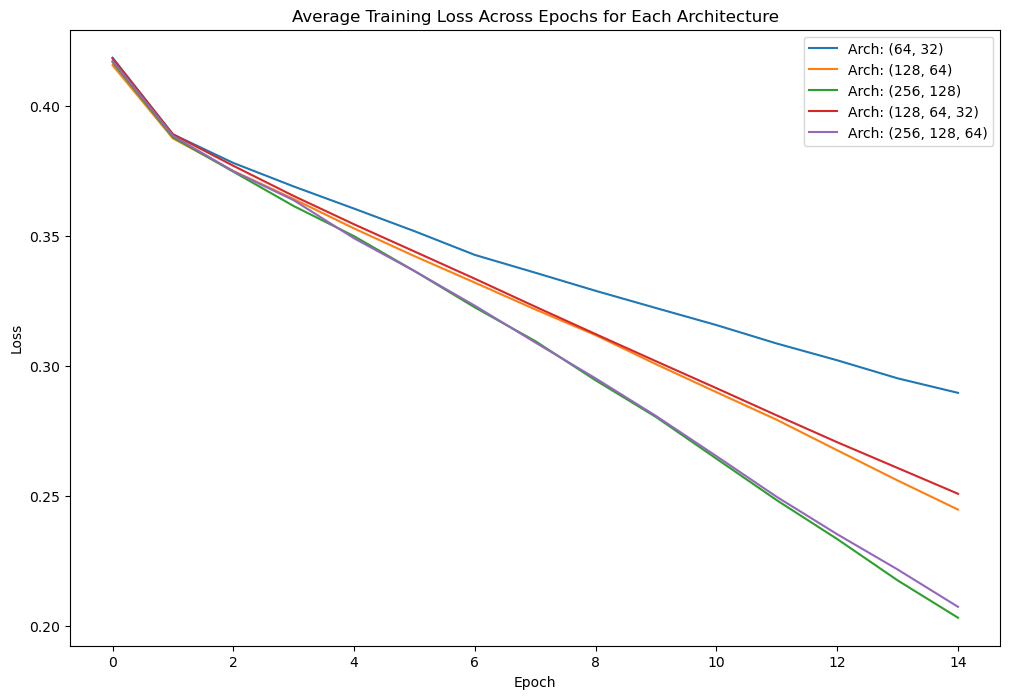

In [5]:
# graph loss history for each architecture (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for config in configs:
    # filter loss history for this architecture
    config_history = [h for h in loss_history if h["architecture"] == config]

    min_len = min(len(h["losses"]) for h in config_history)

    aligned_losses = [
        h["losses"][:min_len] for h in config_history
    ]
    
    # average losses across seeds
    avg_losses = np.mean(aligned_losses, axis=0)
    
    plt.plot(avg_losses, label=f"Arch: {config}")

plt.title("Average Training Loss Across Epochs for Each Architecture")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **[5]** Error Analysis and Model Tuning

For each class, the following metrics were used.  

1. Balanced Accuracy
2. Precision (Rural)
3. Precision (Urban)
4. Recall (Rural)
5. Recall (Urban)
6. F1-score (Rural)
7. F1-score (Urban)
8. Log Loss
9. Area under the receiving operating characteristic curve - ROC-AUC
10. Area under the precision recall curve - PR-AUC

Balanced accuracy, which is the average of the recall on each class, is more effective for classification problems on imbalanced sets. Between the **urban (class 1)** and **rural (class 0)** classes in the dataset, rural is the majority class.

$$\text{Balanced Accuracy} = \frac{1}{k} \sum_{i=1}^{k} \text{Recall}_i$$

Separate precision, recall, and f1 metrics were taken for performance in identifying urban and rural classes to consider the imbalance in the classes.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html

In [6]:
# flatten results of comparing different architectures
def flat_results_architecture(training_results):
    results_flat = []
    for r in training_results:
        flat_r = {
            "architecture": r["architecture"],
            "train_balanced_accuracy": r["train_balanced_accuracy"],
            "train_precision_rural": r["train_precision_class 0"],
            "train_precision_urban": r["train_precision_class 1"],
            "train_recall_rural": r["train_recall_class 0"],
            "train_recall_urban": r["train_recall_class 1"],
            "train_f1_rural": r["train_f1_class 0"],
            "train_f1_urban": r["train_f1_class 1"],
            "train_log_loss": r["train_log_loss"],
            "train_ROC_AUC": r["train_ROC_AUC"],
            "train_PR_AUC": r["train_PR_AUC"],
            "val_balanced_accuracy": r["val_balanced_accuracy"],
            "val_precision_rural": r["val_precision_class 0"],
            "val_precision_urban": r["val_precision_class 1"],
            "val_recall_rural": r["val_recall_class 0"],
            "val_recall_urban": r["val_recall_class 1"],
            "val_f1_rural": r["val_f1_class 0"],
            "val_f1_urban": r["val_f1_class 1"],
            "val_log_loss": r["val_log_loss"],
            "val_ROC_AUC": r["val_ROC_AUC"],
            "val_PR_AUC": r["val_PR_AUC"],
        }
        results_flat.append(flat_r)
    return results_flat

In [7]:
def get_confusion_matrices(training_results):
    results_flat = []
    for r in training_results:
        flat_r = {
            "architecture": r.get("architecture"),
            "learning_rate": r.get("learning_rate"),
            "batch_size": r.get("batch_size"),
            "train_confusion_matrix": r.get("train_confusion_matrix"),
            "val_confusion_matrix": r.get("val_confusion_matrix"),
            "test_confusion_matrix": r.get("test_confusion_matrix")
        }
        results_flat.append(flat_r)
    return results_flat

In [8]:
cms = get_confusion_matrices(results)

Visualize the confusion matrices of each architecture on training and validation to get a better idea of which type of errors are more common.

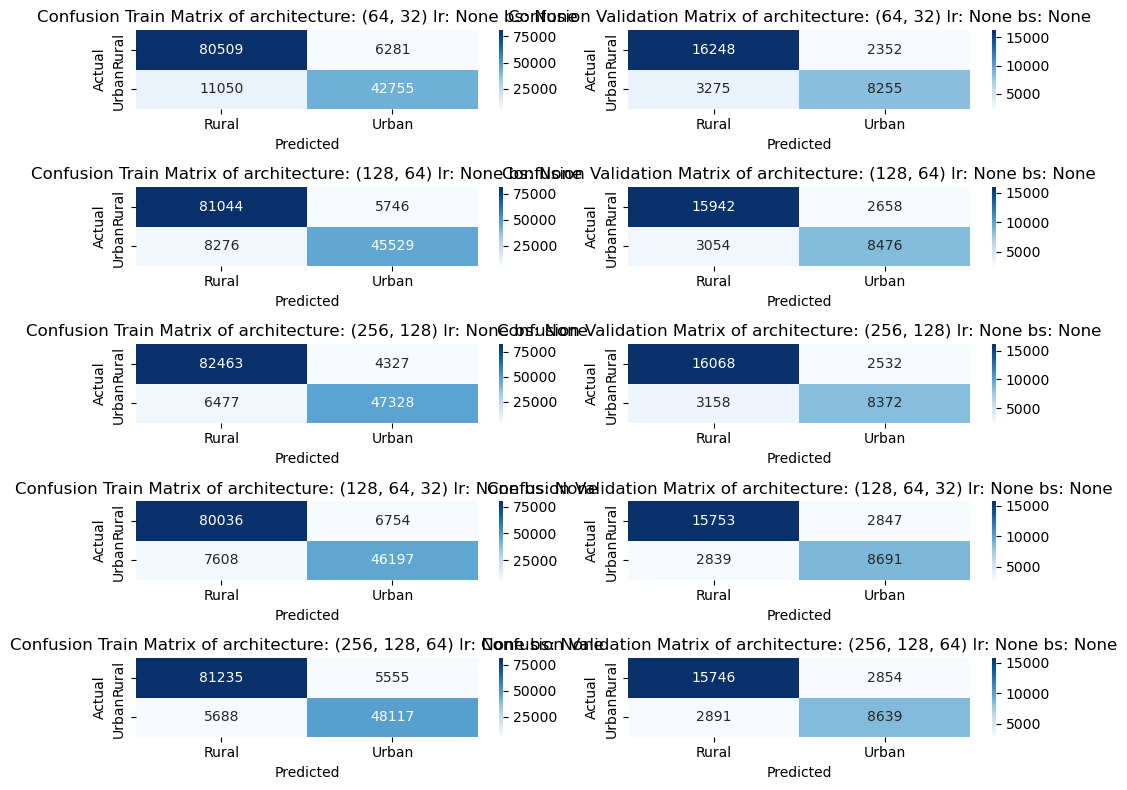

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(cm, axes, i, labels=[0,1], title="Confusion Matrix", single=False):
    if (single):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(title)
        plt.show()
    else:
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[i]
        )
        
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")
        axes[i].set_title(title)

# Grid size
def subplot_cm(matrices, a_cols, a_figsize=(10,8)):
    n_models = len(matrices) * 2
    cols = a_cols
    rows = (n_models + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=a_figsize)
    axes = axes.flatten()

    i = 0
    for c_matrix in matrices:
        plot_cm(c_matrix["train_confusion_matrix"], axes, i , labels=['Rural','Urban'], title=f"Confusion Train Matrix of architecture: {c_matrix.get("architecture")} lr: {c_matrix.get("learning_rate")} bs: {c_matrix.get("batch_size")}")
        i += 1
        plot_cm(c_matrix["val_confusion_matrix"], axes, i, labels=['Rural','Urban'], title=f"Confusion Validation Matrix of architecture: {c_matrix.get("architecture")} lr: {c_matrix.get("learning_rate")} bs: {c_matrix.get("batch_size")}")
        i += 1

    plt.tight_layout()
    plt.show()


subplot_cm(cms, 2)

Based on the confusion matrices, in general, there are more rural households than urban, and the models were able to correctly predict most labels.

The training and validation metrics of each tested architecture is displayed in tabular form. Training and validation balanced accuracy for each architecture is represented in a bar chart.

In [10]:
results_flat = flat_results_architecture(results)
results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3,4
architecture,"(64, 32)","(128, 64)","(256, 128)","(128, 64, 32)","(256, 128, 64)"
train_balanced_accuracy,0.861129,0.88999,0.914882,0.89039,0.91514
train_precision_rural,0.879473,0.90741,0.927196,0.913345,0.934609
train_precision_urban,0.87262,0.888143,0.916252,0.872795,0.896606
train_recall_rural,0.92763,0.933794,0.950144,0.92218,0.935995
train_recall_urban,0.794629,0.846185,0.879621,0.858601,0.894285
train_f1_rural,0.902801,0.920374,0.938522,0.917659,0.935277
train_f1_urban,0.83145,0.866547,0.897542,0.865433,0.895383
train_log_loss,0.270553,0.218874,0.1734,0.224284,0.1811
train_ROC_AUC,0.951377,0.969098,0.980887,0.967788,0.979787


A comparison between train_balance_accuracy and val_balanced_accuracy reveals a noticeable difference between the performance of all architectures in predicting classes on the training and validation set, which is an indication that all the configurations are overfitting on the training data.

Moreover, the f1-score when determining rural households is higher compared to the f1-score on urban. This is likely due to the class imbalance between urban and rural households in the dataset, where there are much more rural than urban.

However, the high values of Receiver Operating Characteristic - Area Under Curve indicates that the model was able to distinguish between these classes well, while the Precision Recall Characteristic - Area Under Curve indicates that it was still able to handle the minority class well despite the imbalance.

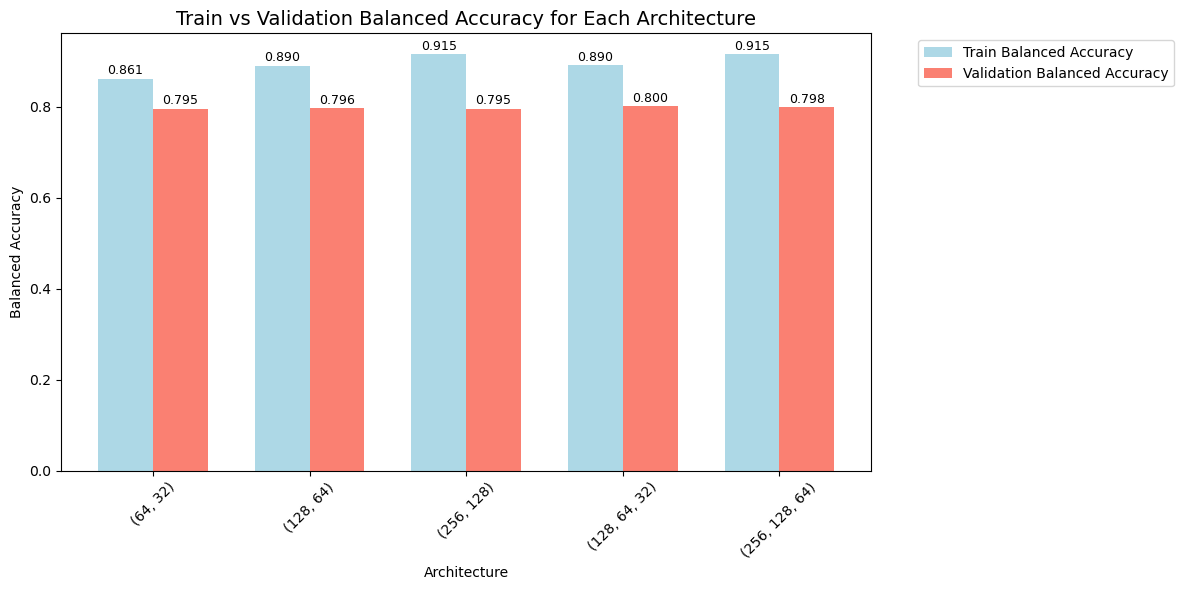

In [11]:
# see distribution of balanced accuracy scores in the training and validation set across different architectures
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["architecture"]))
bar_width = 0.35
plt.bar(x - bar_width/2, results_df["train_balanced_accuracy"], width=bar_width, label='Train Balanced Accuracy', color='lightblue')
plt.bar(x + bar_width/2, results_df["val_balanced_accuracy"], width=bar_width, label='Validation Balanced Accuracy', color='salmon')
plt.title("Train vs Validation Balanced Accuracy for Each Architecture", fontsize=14)
plt.xlabel("Architecture")
plt.ylabel("Balanced Accuracy")
# position legend outside the plot area to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(x, results_df["architecture"], rotation=45)
plt.tight_layout()

# allow user to see the values on top of the bars
for i in range(len(results_df)):
    plt.text(i - bar_width/2, results_df["train_balanced_accuracy"].iloc[i] + 0.01, f"{results_df['train_balanced_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    plt.text(i + bar_width/2, results_df["val_balanced_accuracy"].iloc[i] + 0.01, f"{results_df['val_balanced_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

plt.show()

All architectures in the preliminary test had a similar validation balanced accuracy of approximately 0.8. Balanced accuracy is used as the primary metric for comparison because it gives equal weight to both the urban and rural classes. Given that the difference between the train and test balanced accuracy is greater than 5 percent, all architectures tested are likely overfitting on the training data. Thus, simpler architectures with better potential for generalization should be compared.  

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html  
https://iterate.ai/ai-glossary/balanced-accuracy  

In [12]:
learning_rate = 0.005
# the relatively small epoch limit is now a safeguard to prevent overfitting
epoch_limit = 15

seeds = [0, 42, 123, 456, 789]  # different for multiple runs

# Define different architectures to test (number of hidden layers and their sizes)
configs = [
    (32, 16),
    (16, 8),
    (8,4),
    (4,2)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train and evaluate the neural network for each architecture configuration
criterion = nn.CrossEntropyLoss()
data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=64)

for hidden_layers in configs:

    run_metrics = []  # to store metrics for this architecture

    for seed in seeds:
        # Set seeds for reproducibility
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

        network = NeuralNetwork(
            input_size=input_size,
            list_hidden=hidden_layers,
            activation='relu',
            num_classes=2
        )

        print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}")

        network.create_network()

        optimizer = optim.Adam(network.parameters(), lr=learning_rate)

        training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

        loss_history.append({
            "architecture": hidden_layers,
            "seed": seed,
            "losses": training_losses
        })

        # evaluate on both train and validation sets
        trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
        evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

        # store metrics of this run
        run_metrics.append({
            "train": trainMetrics,
            "val": evalMetrics
        })

    # Collect all training confusion matrices
    train_cms = [r['train']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['train']]
    avg_train_cm = np.sum(train_cms, axis=0)

    # Collect all validation confusion matrices
    val_cms = [r['val']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['val']]
    avg_val_cm = np.sum(val_cms, axis=0)

    # Compute averages across runs
    avg_train_metrics = {}
    for k, v in run_metrics[0]["train"].items():
        # Skip the confusion matrix here
        if k == 'confusion_matrix':
            continue
        if isinstance(v, dict):  # nested dict
            for subk in v:
                avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
        else:  # simple float
            avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
    
    avg_val_metrics = {}
    for k, v in run_metrics[0]["val"].items():
        if k == 'confusion_matrix':
            continue
        if isinstance(v, dict):
            for subk in v:
                avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
        else:
            avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])
    
    avg_train_metrics['confusion_matrix'] = avg_train_cm
    avg_val_metrics['confusion_matrix'] = avg_val_cm

    # append averaged results for this architecture
    results.append({
        "architecture": hidden_layers,
        **{"train_" + k: v for k, v in avg_train_metrics.items()},
        **{"val_" + k: v for k, v in avg_val_metrics.items()}
    })


Training Neural Network with hidden layers: (32, 16), seed: 0
Epoch: 1 	Loss: 0.426353
Epoch: 2 	Loss: 0.392050
Epoch: 3 	Loss: 0.383609
Epoch: 4 	Loss: 0.375591
Epoch: 5 	Loss: 0.369270
Epoch: 6 	Loss: 0.361788
Epoch: 7 	Loss: 0.356829
Epoch: 8 	Loss: 0.349840
Epoch: 9 	Loss: 0.345767
Epoch: 10 	Loss: 0.343189
Epoch: 11 	Loss: 0.336998
Epoch: 12 	Loss: 0.334670
Epoch: 13 	Loss: 0.330165
Epoch: 14 	Loss: 0.326885
Epoch: 15 	Loss: 0.326080

Training Neural Network with hidden layers: (32, 16), seed: 42
Epoch: 1 	Loss: 0.424674
Epoch: 2 	Loss: 0.391853
Epoch: 3 	Loss: 0.382648
Epoch: 4 	Loss: 0.375435
Epoch: 5 	Loss: 0.369765
Epoch: 6 	Loss: 0.364013
Epoch: 7 	Loss: 0.358199
Epoch: 8 	Loss: 0.353803
Epoch: 9 	Loss: 0.350913
Epoch: 10 	Loss: 0.346681
Epoch: 11 	Loss: 0.341388
Epoch: 12 	Loss: 0.338674
Epoch: 13 	Loss: 0.334500
Epoch: 14 	Loss: 0.331950
Epoch: 15 	Loss: 0.330064

Training Neural Network with hidden layers: (32, 16), seed: 123
Epoch: 1 	Loss: 0.425229
Epoch: 2 	Loss: 0.391

c:\Users\james\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\james\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch: 1 	Loss: 0.449832
Epoch: 2 	Loss: 0.401607
Epoch: 3 	Loss: 0.395260
Epoch: 4 	Loss: 0.391573
Epoch: 5 	Loss: 0.389875
Epoch: 6 	Loss: 0.388368
Epoch: 7 	Loss: 0.387114
Epoch: 8 	Loss: 0.385451
Epoch: 9 	Loss: 0.386116
Epoch: 10 	Loss: 0.382688
Epoch: 11 	Loss: 0.383158
Epoch: 12 	Loss: 0.382863
Epoch: 13 	Loss: 0.382788
Epoch: 14 	Loss: 0.382047
Epoch: 15 	Loss: 0.381875


Training loss across epochs for each architecture is visualized in a line graph. The architecture (32,16) has a faster drop in loss than (16,8). Both have noticeably less drop in training loss across epochs compared to the previously evaluated models.

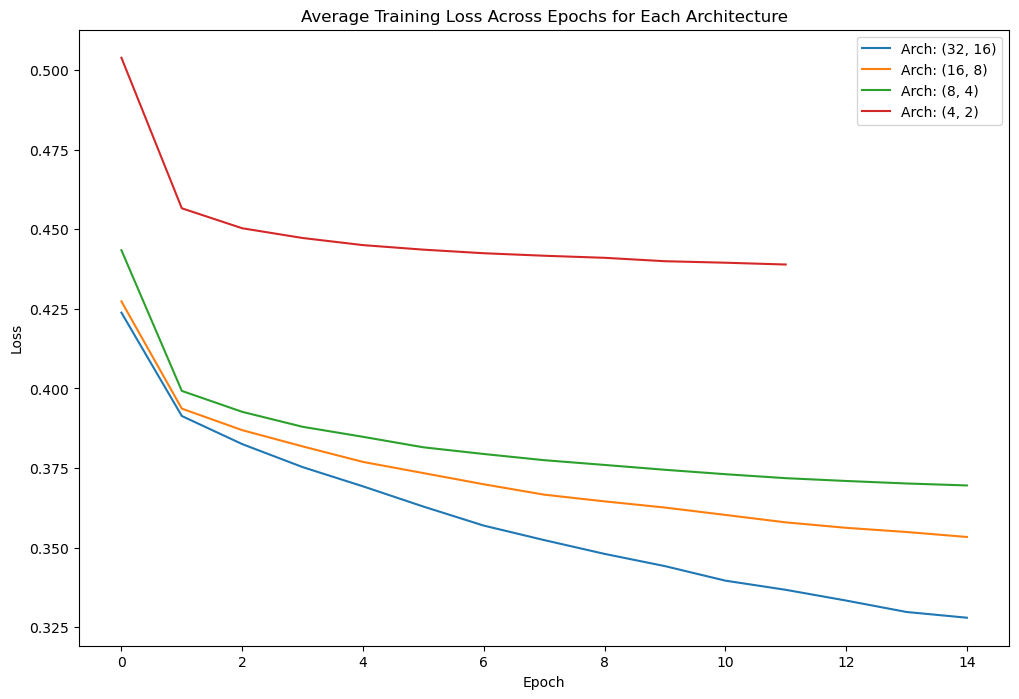

In [13]:
# graph loss history for each architecture (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for config in configs:
    # filter loss history for this architecture
    config_history = [h for h in loss_history if h["architecture"] == config]

    min_len = min(len(h["losses"]) for h in config_history)

    aligned_losses = [
        h["losses"][:min_len] for h in config_history
    ]
    
    # average losses across seeds
    avg_losses = np.mean(aligned_losses, axis=0)
    
    plt.plot(avg_losses, label=f"Arch: {config}")

plt.title("Average Training Loss Across Epochs for Each Architecture")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Visualize the confusion matrices of each architecture on training and validation to get a better idea of which type of errors are more common.

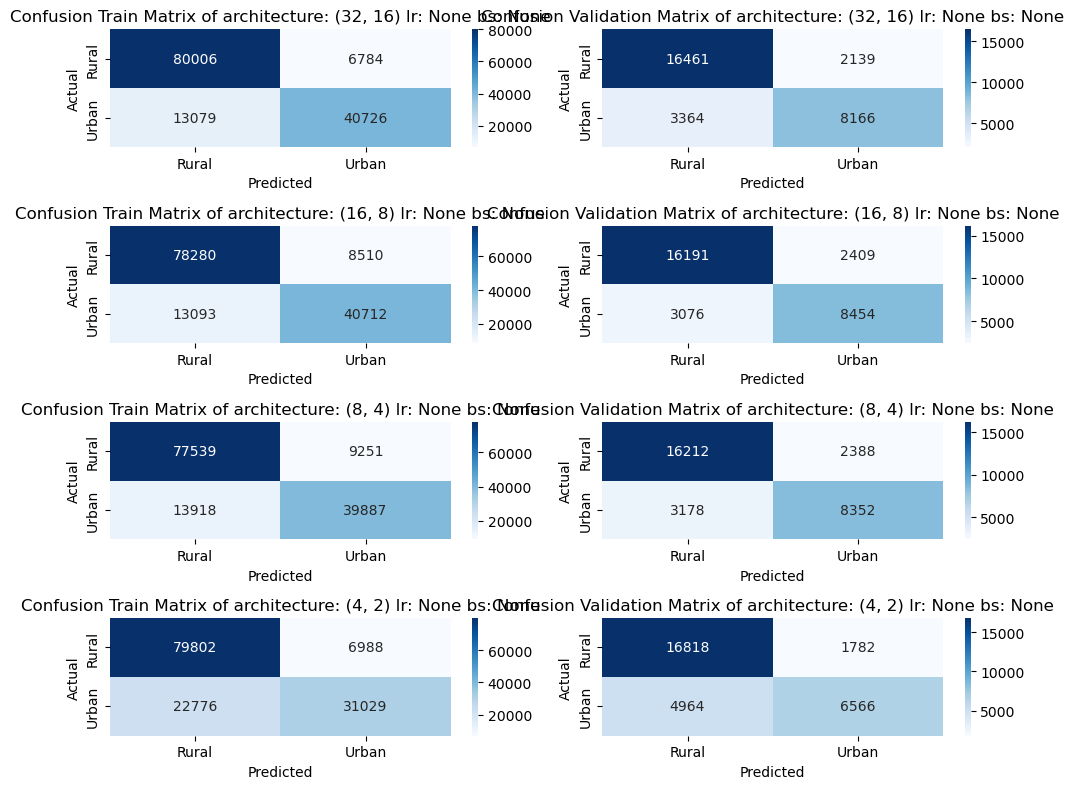

In [14]:
cms = get_confusion_matrices(results)
subplot_cm(cms,2)

The confusion matrices after the last grid search show that although majority of predictions are still correct, the simpler architectures tend to misclassify more urban households as rural than rural as urban, with the architecture having hidden layer configuration (4,2) making this error more frequently than the others.

In [15]:
results_flat = flat_results_architecture(results)
results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3
architecture,"(32, 16)","(16, 8)","(8, 4)","(4, 2)"
train_balanced_accuracy,0.839376,0.829303,0.817367,0.748089
train_precision_rural,0.859637,0.856983,0.847999,0.794483
train_precision_urban,0.857398,0.828106,0.812359,0.653428
train_recall_rural,0.921834,0.901947,0.893409,0.919484
train_recall_urban,0.756919,0.756658,0.741325,0.576694
train_f1_rural,0.889591,0.878709,0.869993,0.847004
train_f1_urban,0.803821,0.79021,0.774852,0.612403
train_log_loss,0.31544,0.344722,0.365833,0.434301
train_ROC_AUC,0.932101,0.917397,0.905237,0.818493


A comparison between train_balance_accuracy and val_balanced_accuracy after this grid search shows less difference between the performance of the simpler architectures in predicting classes on the training and validation set, which is an indication that these simpler configurations may not be overfitting on training data.

The f1-score when determining rural households is still higher compared to the f1-score on urban. However, the values of Receiver Operating Characteristic - Area Under Curve and the Precision Recall Characteristic - Area Under Curve remain high, indicating that the models were still able to distinguish between the classes fairly well.

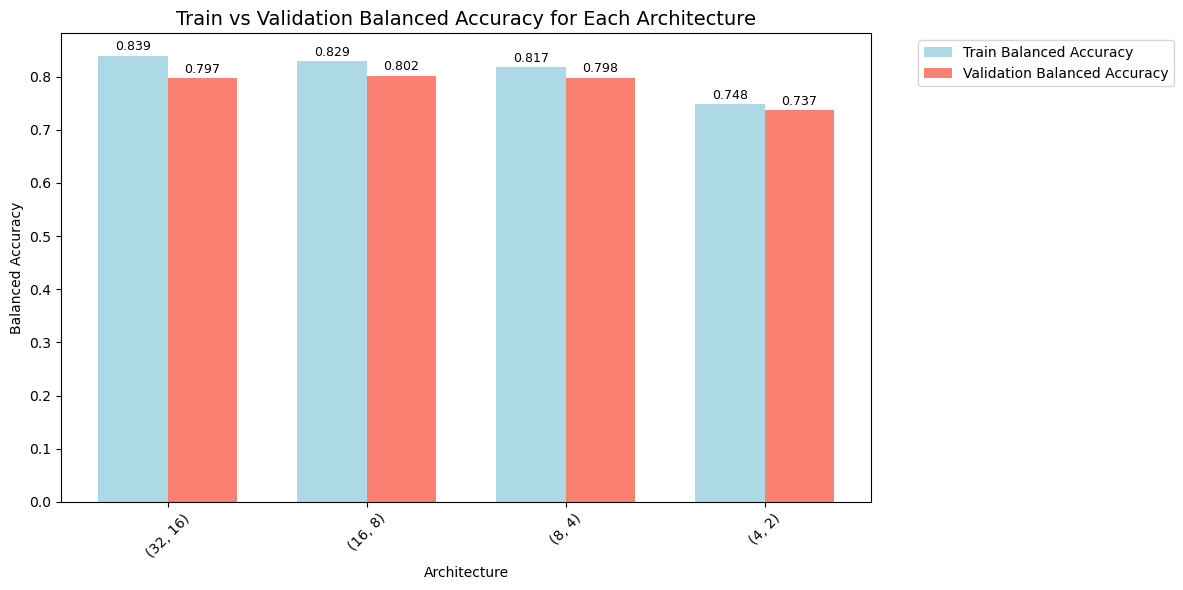

In [16]:
# see distribution of balanced accuracy scores in the training and validation set across different architectures
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["architecture"]))
bar_width = 0.35
plt.bar(x - bar_width/2, results_df["train_balanced_accuracy"], width=bar_width, label='Train Balanced Accuracy', color='lightblue')
plt.bar(x + bar_width/2, results_df["val_balanced_accuracy"], width=bar_width, label='Validation Balanced Accuracy', color='salmon')
plt.title("Train vs Validation Balanced Accuracy for Each Architecture", fontsize=14)
plt.xlabel("Architecture")
plt.ylabel("Balanced Accuracy")
# position legend outside the plot area to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(x, results_df["architecture"], rotation=45)
plt.tight_layout()

# allow user to see the values on top of the bars
for i in range(len(results_df)):
    plt.text(i - bar_width/2, results_df["train_balanced_accuracy"].iloc[i] + 0.01, f"{results_df['train_balanced_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    plt.text(i + bar_width/2, results_df["val_balanced_accuracy"].iloc[i] + 0.01, f"{results_df['val_balanced_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

The smaller architectures show lesser differences between training and validation balanced accuracies, compared to the previously tested set of architectures, with the difference between validation and training balanced accuracy decreasing as the architecture gets simpler. The validation balanced accuracy scores of architecture configurations (32,16), (16,8), and (8,4) are roughly the same at approximately 0.8, however (4,2) has a noticeably lower value for both training and validation balanced accuracy, indicating that it could be underfitting the data.

Among the configurations that don't risk underfitting, which are (32,16), (16,8), and (8,4), we will proceed to further fine tune a neural network with hidden layer configurations (8,4), as it has the least drop in balanced accuracy of these configurations. The choice of simpler architecture is also justified by the principle of Occam's Razor, where it is reasonable to select the neural network with the lesser neurons among them as this would lead to a similar result as the others, only with less memory consumption.

https://www.geeksforgeeks.org/machine-learning/occams-razor/

Thus, we proceed to fine tine the neural network with 2 hidden layers having a configuration of 8 and 4 neurons respectively.

### Comparison of different Hyperparameter Configurations

Performance of the model on different configurations of learning rates and batch sizes are compared in another grid search.

In [17]:
# increase epoch limit to observe convergence behavior of smaller architectures
epoch_limit = 100
learning_rates = [0.001, 0.005, 0.01]
batch_sizes = [32, 64, 128]

seeds = [0]  # using only one seed to save time.

# Only use one architecture
configs = [
    (8,4)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train for each learning rate and batch size combination
for lr in learning_rates:
    for bs in batch_sizes:

        # Train and evaluate the neural network for each architecture configuration
        criterion = nn.CrossEntropyLoss()
        data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=bs)

        for hidden_layers in configs:

            run_metrics = []  # to store metrics for this architecture

            for seed in seeds:
                # Set seed for reproducibility
                os.environ['PYTHONHASHSEED'] = str(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.use_deterministic_algorithms(True)

                network = NeuralNetwork(
                    input_size=input_size,
                    list_hidden=hidden_layers,
                    activation='relu',
                    num_classes=2
                )

                print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}, learning rate: {lr}, batch size: {bs}")

                network.create_network()

                optimizer = optim.Adam(network.parameters(), lr=lr)

                training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

                loss_history.append({
                    "architecture": hidden_layers,
                    "seed": seed,
                    "learning_rate": lr,
                    "batch_size": bs,
                    "losses": training_losses
                })

                # evaluate on both train and validation sets
                trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
                evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

                # store metrics of this run
                run_metrics.append({
                    "train": trainMetrics,
                    "val": evalMetrics
                })

            # Collect all training confusion matrices
            train_cms = [r['train']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['train']]
            avg_train_cm = np.sum(train_cms, axis=0)

            # Collect all validation confusion matrices
            val_cms = [r['val']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['val']]
            avg_val_cm = np.sum(val_cms, axis=0)

            # Compute averages across runs
            avg_train_metrics = {}
            for k, v in run_metrics[0]["train"].items():
                # Skip the confusion matrix here
                if k == 'confusion_matrix':
                    continue
                if isinstance(v, dict):  # nested dict
                    for subk in v:
                        avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
                else:  # simple float
                    avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
            
            avg_val_metrics = {}
            for k, v in run_metrics[0]["val"].items():
                if k == 'confusion_matrix':
                    continue
                if isinstance(v, dict):
                    for subk in v:
                        avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
                else:
                    avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])
            
            avg_train_metrics['confusion_matrix'] = avg_train_cm
            avg_val_metrics['confusion_matrix'] = avg_val_cm

            # append averaged results for this architecture
            results.append({
                "architecture": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                **{"train_" + k: v for k, v in avg_train_metrics.items()},
                **{"val_" + k: v for k, v in avg_val_metrics.items()}
            })


Training Neural Network with hidden layers: (8, 4), seed: 0, learning rate: 0.001, batch size: 32
Epoch: 1 	Loss: 0.475088
Epoch: 2 	Loss: 0.399182
Epoch: 3 	Loss: 0.394225
Epoch: 4 	Loss: 0.390685
Epoch: 5 	Loss: 0.388170
Epoch: 6 	Loss: 0.385790
Epoch: 7 	Loss: 0.383995
Epoch: 8 	Loss: 0.381753
Epoch: 9 	Loss: 0.380692
Epoch: 10 	Loss: 0.380026
Epoch: 11 	Loss: 0.378054
Epoch: 12 	Loss: 0.377262
Epoch: 13 	Loss: 0.375763
Epoch: 14 	Loss: 0.374444
Epoch: 15 	Loss: 0.373821
Epoch: 16 	Loss: 0.372977
Epoch: 17 	Loss: 0.372678
Epoch: 18 	Loss: 0.371372
Epoch: 19 	Loss: 0.370148
Epoch: 20 	Loss: 0.370246
Epoch: 21 	Loss: 0.369678
Epoch: 22 	Loss: 0.369624
Epoch: 23 	Loss: 0.368522
Epoch: 24 	Loss: 0.367127
Epoch: 25 	Loss: 0.367399
Epoch: 26 	Loss: 0.366266
Epoch: 27 	Loss: 0.365942
Epoch: 28 	Loss: 0.365555
Epoch: 29 	Loss: 0.365939
Epoch: 30 	Loss: 0.364912
Epoch: 31 	Loss: 0.364831
Epoch: 32 	Loss: 0.363954
Epoch: 33 	Loss: 0.363787
Epoch: 34 	Loss: 0.363872
Epoch: 35 	Loss: 0.362903


Training loss over epochs for each combination of hyperparameter is visualized in a line graph. Majority of the reduction in loss can be observed before the 20th epoch.

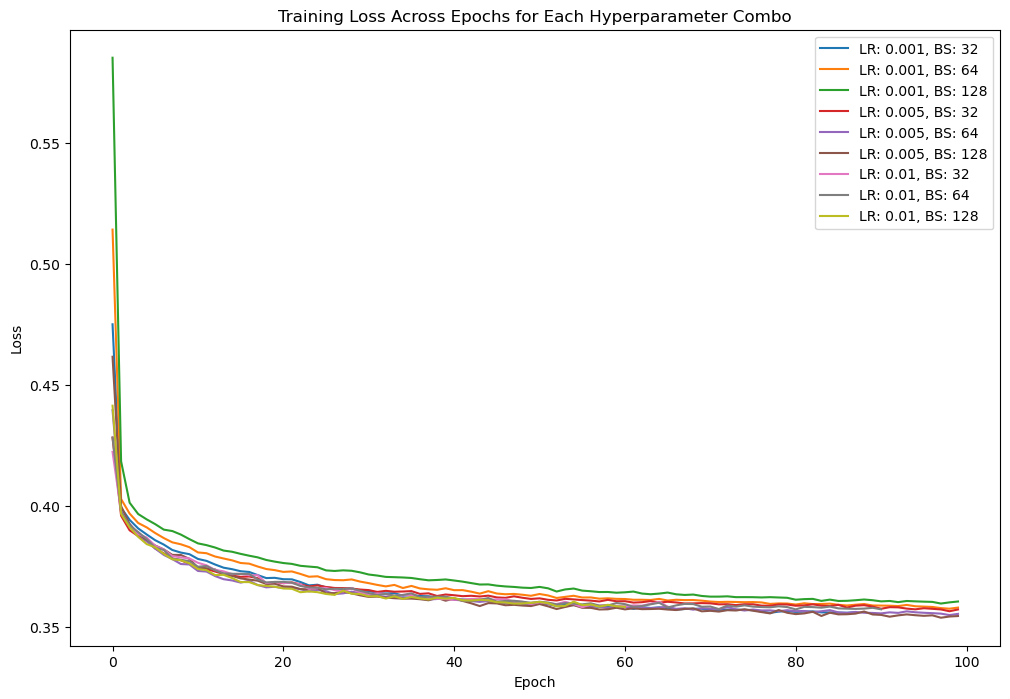

In [18]:
# graph loss history for each learning rate and batch size combination
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for lr in learning_rates:
    for bs in batch_sizes:
        # filter loss history for this learning rate and batch size
        config_history = [h for h in loss_history if h["learning_rate"] == lr and h["batch_size"] == bs]

        min_len = min(len(h["losses"]) for h in config_history)

        aligned_losses = [
            h["losses"][:min_len] for h in config_history
        ]
        
        # average losses across seeds
        avg_losses = np.mean(aligned_losses, axis=0)
        
        plt.plot(avg_losses, label=f"LR: {lr}, BS: {bs}")

plt.title("Training Loss Across Epochs for Each Hyperparameter Combo")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Confusion matrices are displayed for each configuration tested.

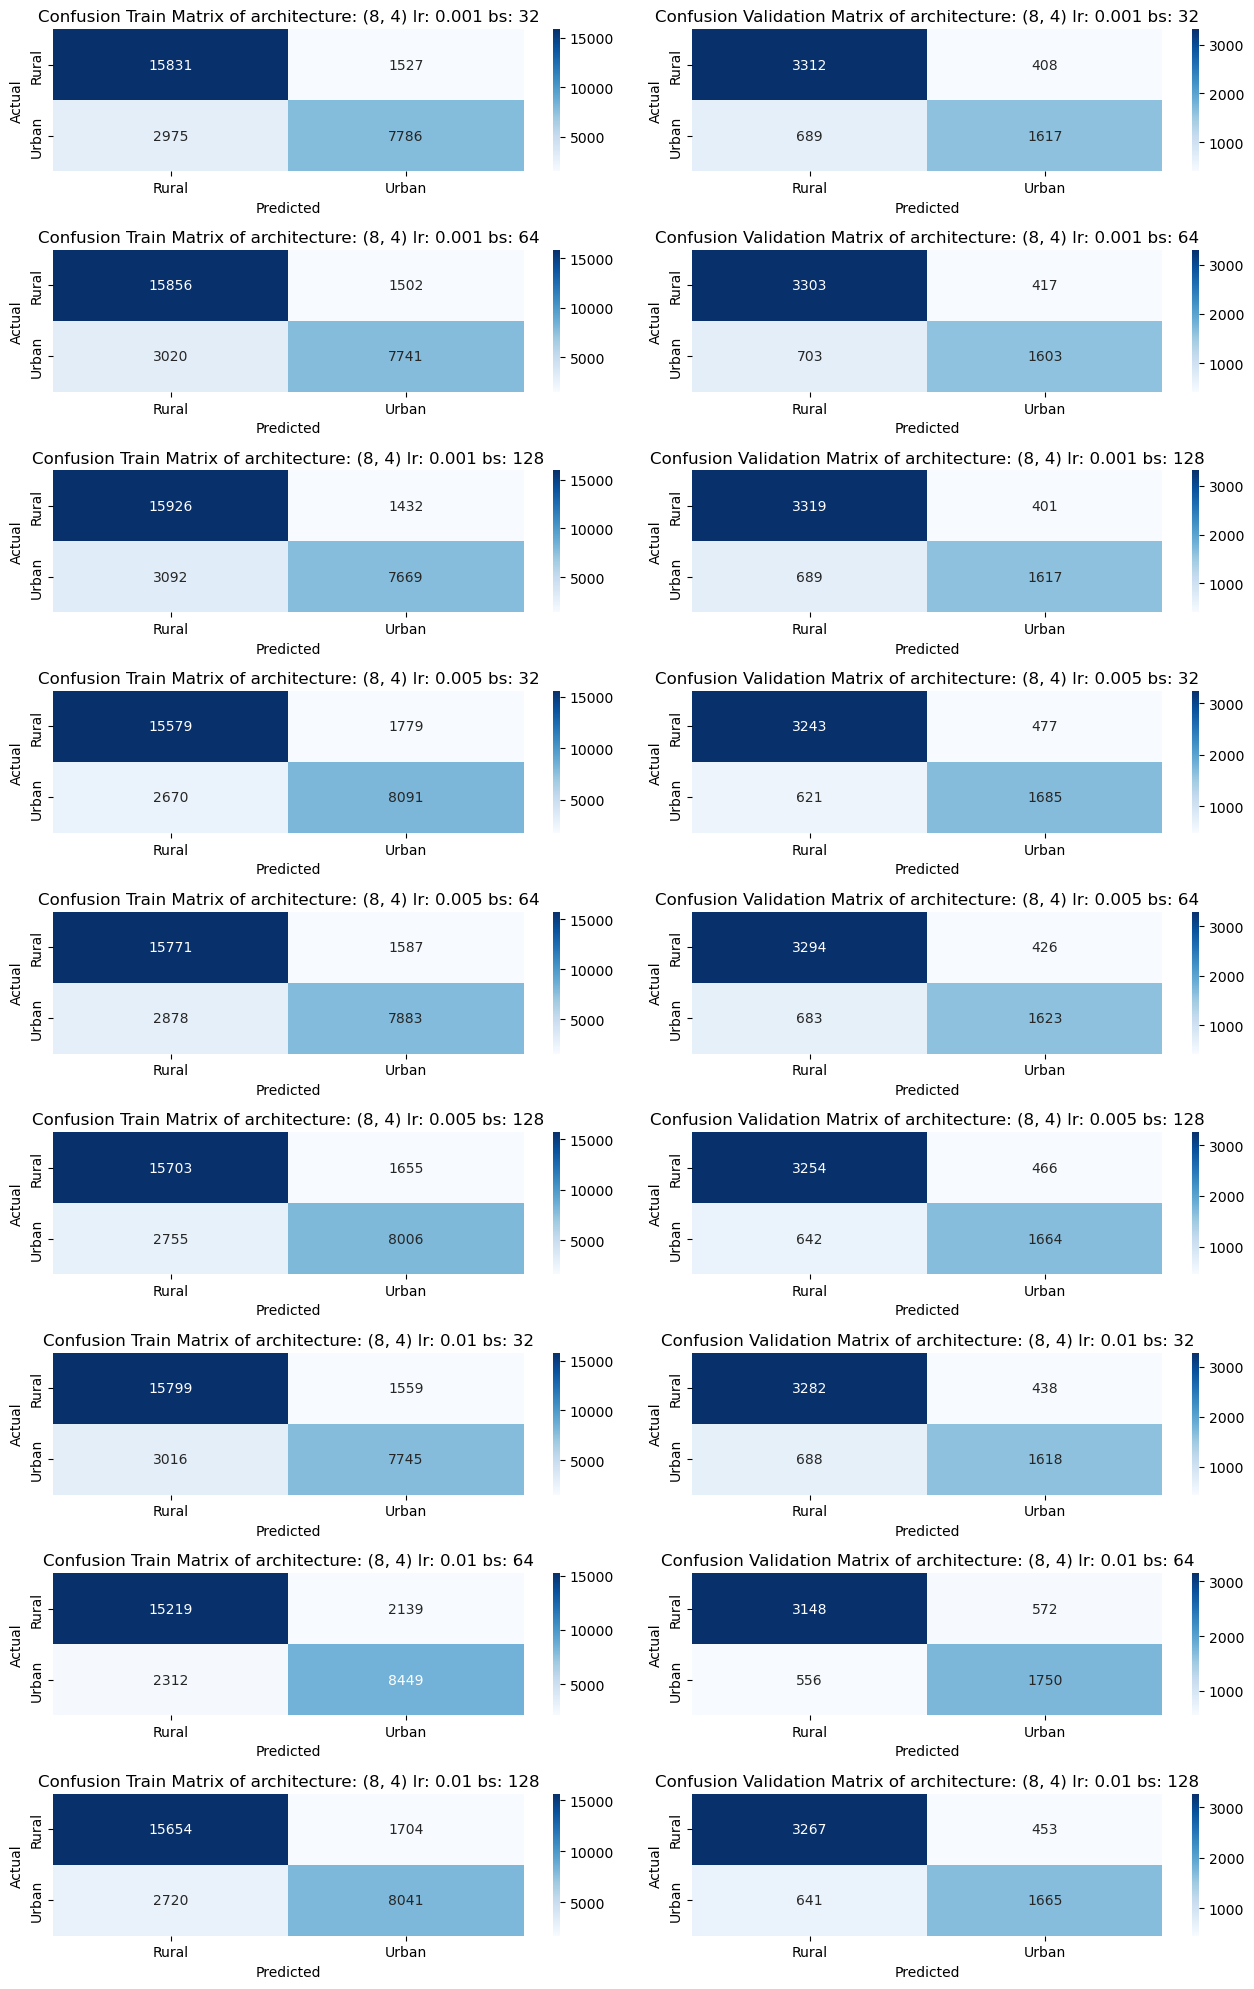

In [19]:
cms = get_confusion_matrices(results)

# for c_matrix in cms:
#     plot_cm(c_matrix["train_confusion_matrix"], axes=None, i=0, labels=['Rural','Urban'], title=f"Confusion Train Matrix (lr:{c_matrix["learning_rate"]}, bs:{c_matrix["batch_size"]})", single=True)
#     plot_cm(c_matrix["val_confusion_matrix"], axes=None, i=0, labels=['Rural','Urban'], title=f"Confusion Validation Matrix (lr:{c_matrix["learning_rate"]}, bs:{c_matrix["batch_size"]})", single=True)

subplot_cm(cms,2,(13,20))

Once again, it can be observed that the models generally misclassify urban as rural more often than they misclassify rural as urban.

The metrics for comparing the different configurations are displayed in table form. Balanced accuracies and f1 scores are visualized with a bar chart.

In [20]:
# flatten results for viewing
def flat_results_LR_BS(results_to_flatten):
    results_flat = []
    for r in results_to_flatten:
        flat_r = {
            "learning_rate": r["learning_rate"],
            "batch_size": r["batch_size"],
            "train_balanced_accuracy": r["train_balanced_accuracy"],
            "train_precision_rural": r["train_precision_class 0"],
            "train_precision_urban": r["train_precision_class 1"],
            "train_recall_rural": r["train_recall_class 0"],
            "train_recall_urban": r["train_recall_class 1"],
            "train_f1_rural": r["train_f1_class 0"],
            "train_f1_urban": r["train_f1_class 1"],
            "train_log_loss": r["train_log_loss"],
            "train_ROC_AUC": r["train_ROC_AUC"],
            "train_PR_AUC": r["train_PR_AUC"],
            "val_balanced_accuracy": r["val_balanced_accuracy"],
            "val_precision_rural": r["val_precision_class 0"],
            "val_precision_urban": r["val_precision_class 1"],
            "val_recall_rural": r["val_recall_class 0"],
            "val_recall_urban": r["val_recall_class 1"],
            "val_f1_rural": r["val_f1_class 0"],
            "val_f1_urban": r["val_f1_class 1"],
            "val_log_loss": r["val_log_loss"],
            "val_ROC_AUC": r["val_ROC_AUC"],
            "val_PR_AUC": r["val_PR_AUC"],
        }
        results_flat.append(flat_r)
    return results_flat

In [21]:
results_flat = flat_results_LR_BS(results)
results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3,4,5,6,7,8
learning_rate,0.001000,0.001000,0.001000,0.005000,0.005000,0.005000,0.010000,0.010000,0.010000
batch_size,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000
train_balanced_accuracy,0.817784,0.816413,0.815084,0.824697,0.820563,0.824319,0.814957,0.830961,0.824534
train_precision_rural,0.841806,0.840008,0.837417,0.853691,0.845675,0.850742,0.839702,0.868119,0.851965
train_precision_urban,0.836036,0.837499,0.842655,0.819757,0.832418,0.828693,0.832438,0.797979,0.825141
train_recall_rural,0.912029,0.913469,0.917502,0.897511,0.908572,0.904655,0.910186,0.876772,0.901832
train_recall_urban,0.723539,0.719357,0.712666,0.751882,0.732553,0.743983,0.719729,0.785150,0.747235
train_f1_rural,0.875512,0.875200,0.875632,0.875053,0.875996,0.876871,0.873524,0.872424,0.876189
train_f1_urban,0.775730,0.773945,0.772228,0.784354,0.779299,0.784056,0.771991,0.791512,0.784258
train_log_loss,0.352978,0.355365,0.358125,0.351608,0.352821,0.350844,0.357823,0.357828,0.357016


Regardless of a slight imbalance in misclassification, and the values of f1 score remaining higher on rural, the values of Receiver Operating Characteristic - Area Under Curve and the Precision Recall Characteristic - Area Under Curve remain high, indicating that the models were still able to properly distinguish between the classes without the need for any adjustment of class weights.

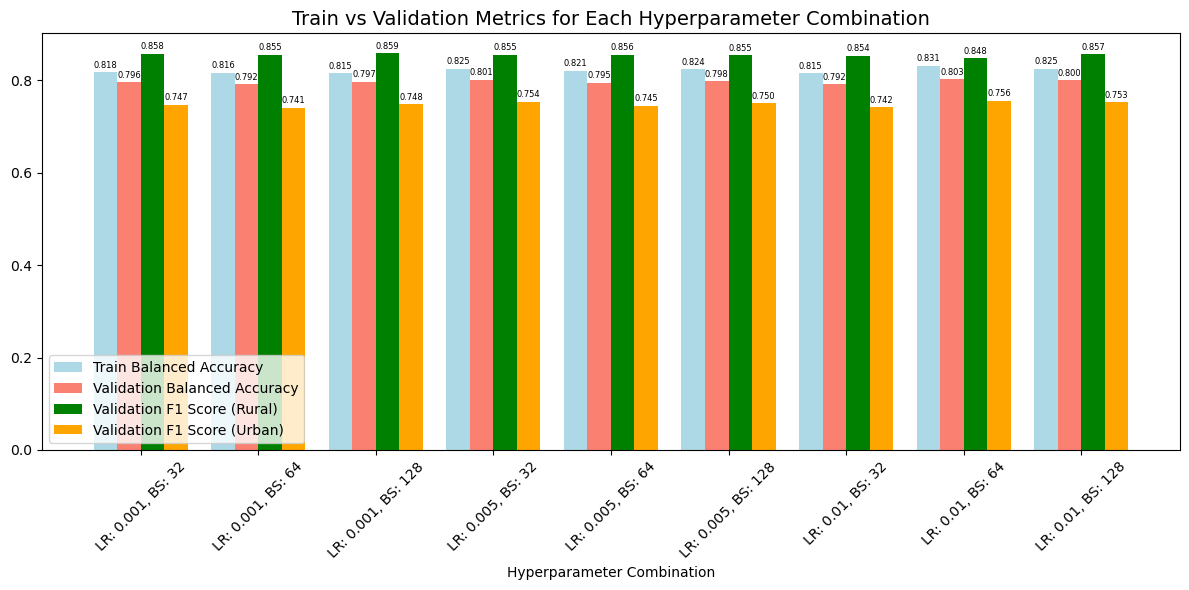

In [22]:
# see comparison of balanced accuracy scores in the training and validation set and f1 scores across
# different combinations of learning rate and batch size using a bar chart
plt.figure(figsize=(12, 6))

# x-axis positions
x = np.arange(len(results_df))

bar_width = 0.2

# Plot bars
plt.bar(x - 1.5*bar_width, results_df["train_balanced_accuracy"], width=bar_width, label='Train Balanced Accuracy', color='lightblue')
plt.bar(x - 0.5*bar_width, results_df["val_balanced_accuracy"], width=bar_width, label='Validation Balanced Accuracy', color='salmon')
plt.bar(x + 0.5*bar_width, results_df["val_f1_rural"], width=bar_width, label='Validation F1 Score (Rural)', color='green')
plt.bar(x + 1.5*bar_width, results_df["val_f1_urban"], width=bar_width, label='Validation F1 Score (Urban)', color='orange')

# Titles and labels
plt.title("Train vs Validation Metrics for Each Hyperparameter Combination", fontsize=14)
plt.xlabel("Hyperparameter Combination")
plt.ylabel(None)
plt.legend()

# X-axis labels
plt.xticks(
    x, 
    [f"LR: {lr}, BS: {bs}" for lr, bs in zip(results_df["learning_rate"], results_df["batch_size"])], 
    rotation=45
)

# Show values on top of bars
for i in range(len(results_df)):
    plt.text(i - 1.5*bar_width, results_df["train_balanced_accuracy"].iloc[i] + 0.01, f"{results_df['train_balanced_accuracy'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i - 0.5*bar_width, results_df["val_balanced_accuracy"].iloc[i] + 0.01, f"{results_df['val_balanced_accuracy'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i + 0.5*bar_width, results_df["val_f1_rural"].iloc[i] + 0.01, f"{results_df['val_f1_rural'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i + 1.5*bar_width, results_df["val_f1_urban"].iloc[i] + 0.01, f"{results_df['val_f1_urban'].iloc[i]:.3f}", ha='center', fontsize=6)

plt.tight_layout()
plt.show()

All hyperparameter configurations tested using the architecture (8,4) resulted in similar training and validation balanced accuracies within 0.80 &plusmn; 0.02. The minimal difference between training and validation accuracies indicate that these models were also able to learn how to classify urban and rural households without overfitting on training data.

Although accuracies and f1 scores of each configuration is similar to one another, the model that trained with a learning rate 0.01 and batch size 128 will be used as it was able to converge within the least number of epochs.

# **[6]** Model Evaluation

Now that the final configurations have been identified, the final model is trained, evaluated, and tested using these configurations and its weights are saved.

In [23]:
# increase epoch limit to observe convergence behavior of smaller architectures
epoch_limit = 100

# this time we only use one configuration
learning_rates = [0.01]
batch_sizes = [128]
seeds = [0]  # using seed for reproduciblity

# Only use one architecture
configs = [
    (8,4)
]

# list to store final weights of the trained model
weights = []

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train for each learning rate and batch size combination
for lr in learning_rates:
    for bs in batch_sizes:

        # Train and evaluate the neural network for each architecture configuration
        criterion = nn.CrossEntropyLoss()
        data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=bs)

        for hidden_layers in configs:

            run_metrics = []  # to store metrics for this architecture

            for seed in seeds:
                # Set seed for reproducibility
                os.environ['PYTHONHASHSEED'] = str(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.use_deterministic_algorithms(True)

                network = NeuralNetwork(
                    input_size=input_size,
                    list_hidden=hidden_layers,
                    activation='relu',
                    num_classes=2
                )

                print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}, learning rate: {lr}, batch size: {bs}")

                network.create_network()

                optimizer = optim.Adam(network.parameters(), lr=lr)

                training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

                loss_history.append({
                    "architecture": hidden_layers,
                    "seed": seed,
                    "learning_rate": lr,
                    "batch_size": bs,
                    "losses": training_losses
                })

                # evaluate on train, validation, and test sets
                trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
                evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)
                testMetrics = evaluateNetwork(network, nn_X_test, nn_y_test)

                # store metrics of this run
                run_metrics.append({
                    "train": trainMetrics,
                    "val": evalMetrics,
                    "test": testMetrics
                })
            
            # Collect all training confusion matrices
            train_cms = [r['train']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['train']]
            avg_train_cm = np.sum(train_cms, axis=0)

            # Collect all validation confusion matrices
            val_cms = [r['val']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['val']]
            avg_val_cm = np.sum(val_cms, axis=0)

            # Collect all test confusion matrices
            test_cms = [r['test']['confusion_matrix'] for r in run_metrics if 'confusion_matrix' in r['val']]
            avg_test_cm = np.sum(test_cms, axis=0)

            # Compute averages across runs
            avg_train_metrics = {}
            for k, v in run_metrics[0]["train"].items():
                # Skip the confusion matrix here
                if k == 'confusion_matrix':
                    continue
                if isinstance(v, dict):  # nested dict
                    for subk in v:
                        avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
                else:  # simple float
                    avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
            
            avg_val_metrics = {}
            for k, v in run_metrics[0]["val"].items():
                if k == 'confusion_matrix':
                    continue
                if isinstance(v, dict):
                    for subk in v:
                        avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
                else:
                    avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])
            
            avg_test_metrics = {}
            for k, v in run_metrics[0]["test"].items():
                if k == 'confusion_matrix':
                    continue
                if isinstance(v, dict):
                    for subk in v:
                        avg_test_metrics[f"{k}_{subk}"] = np.mean([r["test"][k][subk] for r in run_metrics])
                else:
                    avg_test_metrics[k] = np.mean([r["test"][k] for r in run_metrics])
            
            avg_train_metrics['confusion_matrix'] = avg_train_cm
            avg_val_metrics['confusion_matrix'] = avg_val_cm
            avg_test_metrics['confusion_matrix'] = avg_test_cm

            # append averaged results for this architecture
            results.append({
                "architecture": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                **{"train_" + k: v for k, v in avg_train_metrics.items()},
                **{"val_" + k: v for k, v in avg_val_metrics.items()},
                **{"test_" + k: v for k, v in avg_test_metrics.items()}
            })
            
            # store final weights of the trained model
            weights.append({
                "architecture": hidden_layers,
                "seed": seed,
                "learning_rate": lr,
                "batch_size": bs,
                "final_weights": network.state_dict()
            })


Training Neural Network with hidden layers: (8, 4), seed: 0, learning rate: 0.01, batch size: 128
Epoch: 1 	Loss: 0.441431
Epoch: 2 	Loss: 0.396690
Epoch: 3 	Loss: 0.391153
Epoch: 4 	Loss: 0.387200
Epoch: 5 	Loss: 0.384192
Epoch: 6 	Loss: 0.382850
Epoch: 7 	Loss: 0.380131
Epoch: 8 	Loss: 0.377907
Epoch: 9 	Loss: 0.377509
Epoch: 10 	Loss: 0.376233
Epoch: 11 	Loss: 0.373883
Epoch: 12 	Loss: 0.373412
Epoch: 13 	Loss: 0.371396
Epoch: 14 	Loss: 0.371484
Epoch: 15 	Loss: 0.370156
Epoch: 16 	Loss: 0.368500
Epoch: 17 	Loss: 0.368483
Epoch: 18 	Loss: 0.367243
Epoch: 19 	Loss: 0.366921
Epoch: 20 	Loss: 0.366574
Epoch: 21 	Loss: 0.365848
Epoch: 22 	Loss: 0.365719
Epoch: 23 	Loss: 0.364296
Epoch: 24 	Loss: 0.364627
Epoch: 25 	Loss: 0.364321
Epoch: 26 	Loss: 0.363575
Epoch: 27 	Loss: 0.363193
Epoch: 28 	Loss: 0.364937
Epoch: 29 	Loss: 0.363677
Epoch: 30 	Loss: 0.363549
Epoch: 31 	Loss: 0.362573
Epoch: 32 	Loss: 0.362692
Epoch: 33 	Loss: 0.361688
Epoch: 34 	Loss: 0.362598
Epoch: 35 	Loss: 0.361535


Weights of the final model are then saved so they can be reused.

In [24]:
# Name of the directory to save to
dir_name = "processed_data"

# Ensure the directory exists
os.makedirs(dir_name, exist_ok=True)

# Full path to save the file
file_path = os.path.join(dir_name, "final_neural_network_weights.pkl")

# Save the weights
joblib.dump(weights, file_path)
print(f"Model saved to {file_path}")

Model saved to processed_data\final_neural_network_weights.pkl


In [73]:
final_network = network

The final network and its predictions on the test set is also saved to model_outputs directory.

In [74]:
final_network.eval()

with torch.no_grad():
    scores, _ = final_network.forward(nn_X_test)
    probs = torch.sigmoid(scores).squeeze().cpu().numpy()
    y_test_final_predictions = probs.argmax(axis=1)
    final_probs = probs[:, 1]

os.makedirs('model_outputs', exist_ok=True)

# Save the final locked-in model
joblib.dump(network, 'model_outputs/multi_layer_perceptron_final.pkl')

# Create a DataFrame of the Test Set predictions and probabilities
mlp_test_results = pd.DataFrame({
    'Actual_y_test': y_test.reset_index(drop=True),
    'MLP_Predicted_Class': y_test_final_predictions,
    'MLP_Predicted_Probability': final_probs
})

# Export to CSV for easy comparison in the main directory
mlp_test_results.to_csv('model_outputs/mlp_test_predictions.csv', index=False)

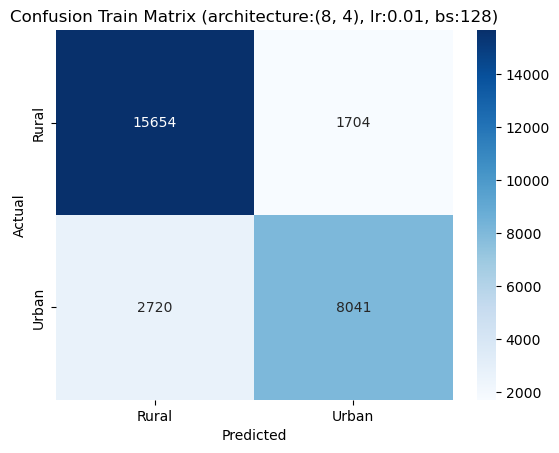

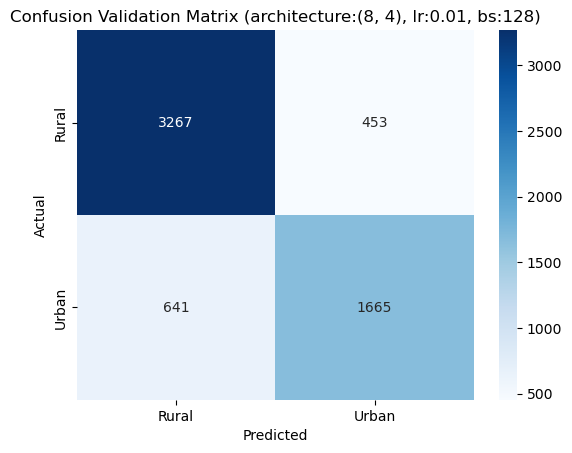

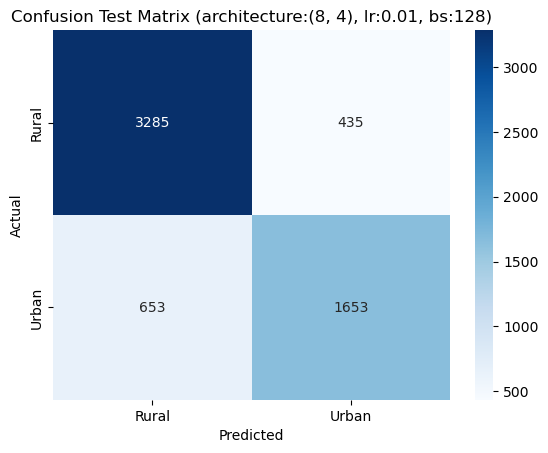

In [75]:
cms = get_confusion_matrices(results)

for c_matrix in cms:
    plot_cm(c_matrix["train_confusion_matrix"], axes=None, i=0, labels=['Rural','Urban'], title=f"Confusion Train Matrix (architecture:{c_matrix["architecture"]}, lr:{c_matrix["learning_rate"]}, bs:{c_matrix["batch_size"]})", single=True)
    plot_cm(c_matrix["val_confusion_matrix"], axes=None, i=0, labels=['Rural','Urban'], title=f"Confusion Validation Matrix (architecture:{c_matrix["architecture"]}, lr:{c_matrix["learning_rate"]}, bs:{c_matrix["batch_size"]})", single=True)
    plot_cm(c_matrix["test_confusion_matrix"], axes=None, i=0, labels=['Rural','Urban'], title=f"Confusion Test Matrix (architecture:{c_matrix["architecture"]}, lr:{c_matrix["learning_rate"]}, bs:{c_matrix["batch_size"]})", single=True)

# subplot_cm(cms,2)

In [76]:
# flatten results for viewing include training metrics
results_flat = []
for r in results:
    flat_r = {
        "learning_rate": r["learning_rate"],
        "batch_size": r["batch_size"],
        "train_balanced_accuracy": r["train_balanced_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "train_log_loss": r["train_log_loss"],
        "train_ROC_AUC": r["train_ROC_AUC"],
        "train_PR_AUC": r["train_PR_AUC"],
        "val_balanced_accuracy": r["val_balanced_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"],
        "val_log_loss": r["val_log_loss"],
        "val_ROC_AUC": r["val_ROC_AUC"],
        "val_PR_AUC": r["val_PR_AUC"],
        "test_balanced_accuracy": r["test_balanced_accuracy"],
        "test_precision_rural": r["test_precision_class 0"],
        "test_precision_urban": r["test_precision_class 1"],
        "test_recall_rural": r["test_recall_class 0"],
        "test_recall_urban": r["test_recall_class 1"],
        "test_f1_rural": r["test_f1_class 0"],
        "test_f1_urban": r["test_f1_class 1"],
        "test_log_loss": r["test_log_loss"],
        "test_ROC_AUC": r["test_ROC_AUC"],
        "test_PR_AUC": r["test_PR_AUC"],
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T

,0
learning_rate,0.010000
batch_size,128.000000
train_balanced_accuracy,0.824534
train_precision_rural,0.851965
train_precision_urban,0.825141
train_recall_rural,0.901832
train_recall_urban,0.747235
train_f1_rural,0.876189
train_f1_urban,0.784258
train_log_loss,0.357016


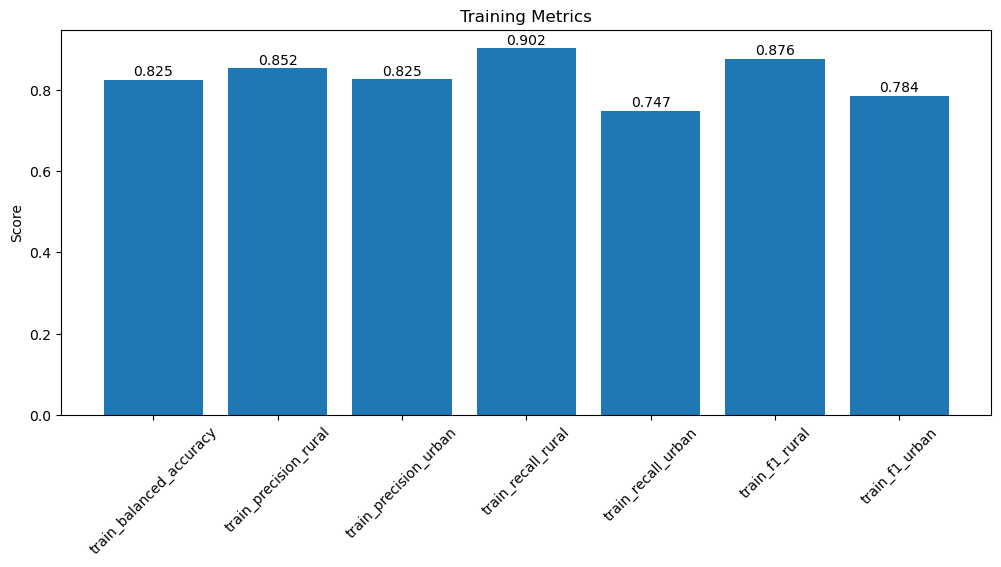

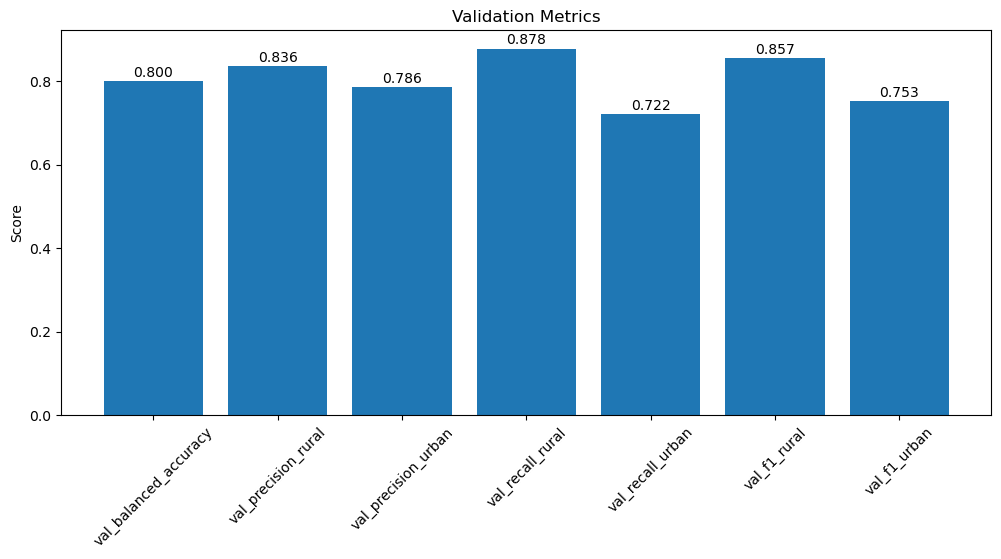

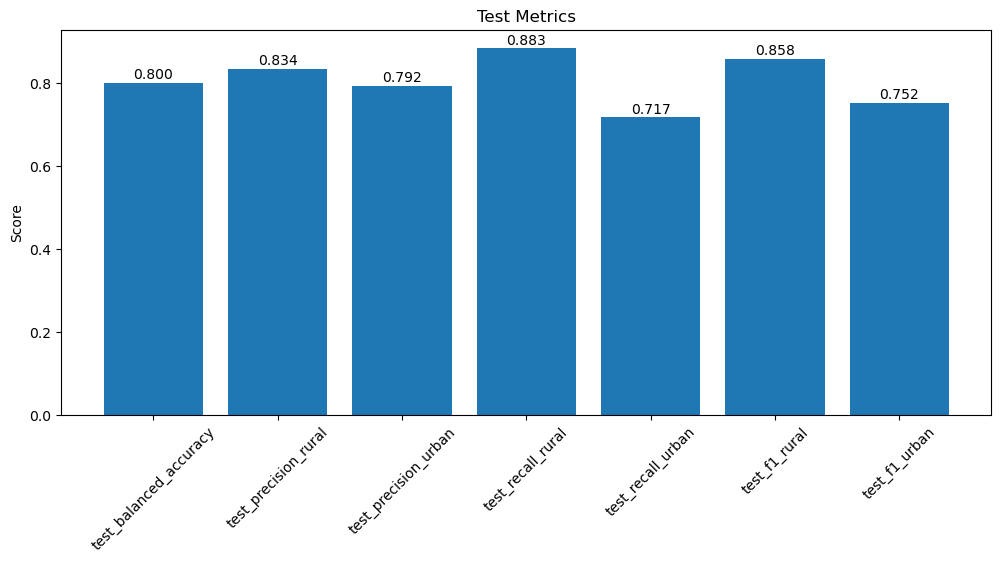

In [77]:
train_output = results_df[["train_balanced_accuracy","train_precision_rural","train_precision_urban","train_recall_rural","train_recall_urban","train_f1_rural","train_f1_urban"]]

row = train_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Training Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

val_output = results_df[["val_balanced_accuracy","val_precision_rural","val_precision_urban","val_recall_rural","val_recall_urban","val_f1_rural","val_f1_urban"]]
val_output

row = val_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Validation Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

test_output = results_df[["test_balanced_accuracy","test_precision_rural","test_precision_urban","test_recall_rural","test_recall_urban","test_f1_rural","test_f1_urban"]]

row = test_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Test Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

In [78]:
final_network

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=85, out_features=8, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=4, out_features=2, bias=True)
    (5): Softmax(dim=1)
  )
)

The final multi-layer perceptron was able to achieve a balanced accuracy within 0.80 &plusmn; 0.03 across all set partitions. This indicates that it was able to successfully learn how to generalize in classifying urban and rural households without overfitting on the training set.

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- Uses ChatGPT to clarify proper flow for training loop
- Uses ChatGPT to assist with understanding errors that came up during debugging
- Uses ChatGPT to clarify errors in python syntax for neural network implementation and training
- Uses Google-search which has AI features in finding sources to justify approaches